In [1]:
import numpy as np
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

In [2]:
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/gender_submission.csv


In [3]:
df = pd.read_csv("/kaggle/input/titanic/train.csv")
tdf = pd.read_csv('/kaggle/input/titanic/test.csv')

test_df = tdf.copy()
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.shape

(891, 12)

In [5]:
df.duplicated().sum()
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [6]:
tdf.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [7]:
df_nan = df.loc[:, df.isnull().any()]
df_nan.isnull().sum()/len(df_nan)*100

Age         19.865320
Cabin       77.104377
Embarked     0.224467
dtype: float64

In [8]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

tdf['Embarked'] = tdf['Embarked'].fillna(tdf['Embarked'].mode()[0])

In [9]:
df['Deck'] = df['Cabin'].apply(lambda x: x[0] if pd.notnull(x) else 'U')
df.drop(columns=['Cabin'], inplace=True)

tdf['Deck'] = tdf['Cabin'].apply(lambda x: x[0] if pd.notnull(x) else 'U')
tdf.drop(columns=['Cabin'], inplace=True)

In [10]:
df['TicketFreq'] = df.groupby('Ticket')['Ticket'].transform('count')

tdf['TicketFreq'] = tdf.groupby('Ticket')['Ticket'].transform('count')

In [11]:
df['Title'] = df['Name'].str.extract(r',\s*([A-Za-z]+)\.')
print(df['Title'].value_counts())

tdf['Title'] = tdf['Name'].str.extract(r',\s*([A-Za-z]+)\.')

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Major         2
Mlle          2
Col           2
Don           1
Mme           1
Ms            1
Lady          1
Sir           1
Capt          1
Jonkheer      1
Name: count, dtype: int64


In [12]:
rare_titles = ['Dr', 'Rev', 'Col', 'Major', 'Mlle', 'Countess', 'Capt', 
               'Ms', 'Sir', 'Lady', 'Don', 'Jonkheer', 'Dona', 'Mme']
df['Title'] = df['Title'].replace(rare_titles, 'Rare')
df['Title'] = df['Title'].replace(['Mlle', 'Ms'], 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs')

tdf['Title'] = tdf['Title'].replace(rare_titles, 'Rare')
tdf['Title'] = tdf['Title'].replace(['Mlle', 'Ms'], 'Miss')
tdf['Title'] = tdf['Title'].replace('Mme', 'Mrs')

In [13]:
df['Age'] = df.groupby('Title')['Age'].transform(lambda x: x.fillna(x.median()))
df['Age'].fillna(df['Age'].median(), inplace=True)
print(df['Age'].isnull().sum())
df.head()

tdf['Age'] = tdf.groupby('Title')['Age'].transform(lambda x: x.fillna(x.median()))
tdf['Age'].fillna(tdf['Age'].median(), inplace=True)
print(tdf['Age'].isnull().sum())

0
0


/tmp/ipykernel_789/3280624468.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_789/3280624468.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

In [14]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
df.head()

tdf['FamilySize'] = tdf['SibSp'] + tdf['Parch'] + 1
tdf['IsAlone'] = (tdf['FamilySize'] == 1).astype(int)

In [15]:
def categorize_age(age):
    if pd.isna(age):
        return 'Unknown'
    elif age < 3:
        return 'Baby'
    elif age < 12:
        return "Child"
    elif age < 18:
        return 'Teen'
    elif age < 30:
        return 'Young'
    elif age <= 50:
        return 'Adult'
    else:
        return 'Senior'

In [16]:
df['AgeGroup'] = df['Age'].apply(categorize_age)
df.head()

tdf['AgeGroup'] = tdf['Age'].apply(categorize_age)

In [17]:
df['FamilySize'] = df['FamilySize'].replace(0, 1)
df['FarePerPerson'] = df['Fare'] / df['FamilySize']

tdf['FamilySize'] = tdf['FamilySize'].replace(0, 1)
tdf['FarePerPerson'] = tdf['Fare'] / tdf['FamilySize']

In [18]:
def ticket_group(freq):
    if freq == 1:
        return 'Single'
    elif freq <=4:
        'SmallGroup'
    else:
        'LargeGroup'

In [19]:
df['TicketGroup'] = df['TicketFreq'].apply(ticket_group)

tdf['TicketGroup'] = tdf['TicketFreq'].apply(ticket_group)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   PassengerId    891 non-null    int64  
 1   Survived       891 non-null    int64  
 2   Pclass         891 non-null    int64  
 3   Name           891 non-null    object 
 4   Sex            891 non-null    object 
 5   Age            891 non-null    float64
 6   SibSp          891 non-null    int64  
 7   Parch          891 non-null    int64  
 8   Ticket         891 non-null    object 
 9   Fare           891 non-null    float64
 10  Embarked       891 non-null    object 
 11  Deck           891 non-null    object 
 12  TicketFreq     891 non-null    int64  
 13  Title          890 non-null    object 
 14  FamilySize     891 non-null    int64  
 15  IsAlone        891 non-null    int64  
 16  AgeGroup       891 non-null    object 
 17  FarePerPerson  891 non-null    float64
 18  TicketGrou

In [21]:
tdf.isnull().sum()

PassengerId       0
Pclass            0
Name              0
Sex               0
Age               0
SibSp             0
Parch             0
Ticket            0
Fare              1
Embarked          0
Deck              0
TicketFreq        0
Title             0
FamilySize        0
IsAlone           0
AgeGroup          0
FarePerPerson     1
TicketGroup      97
dtype: int64

### EDA

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


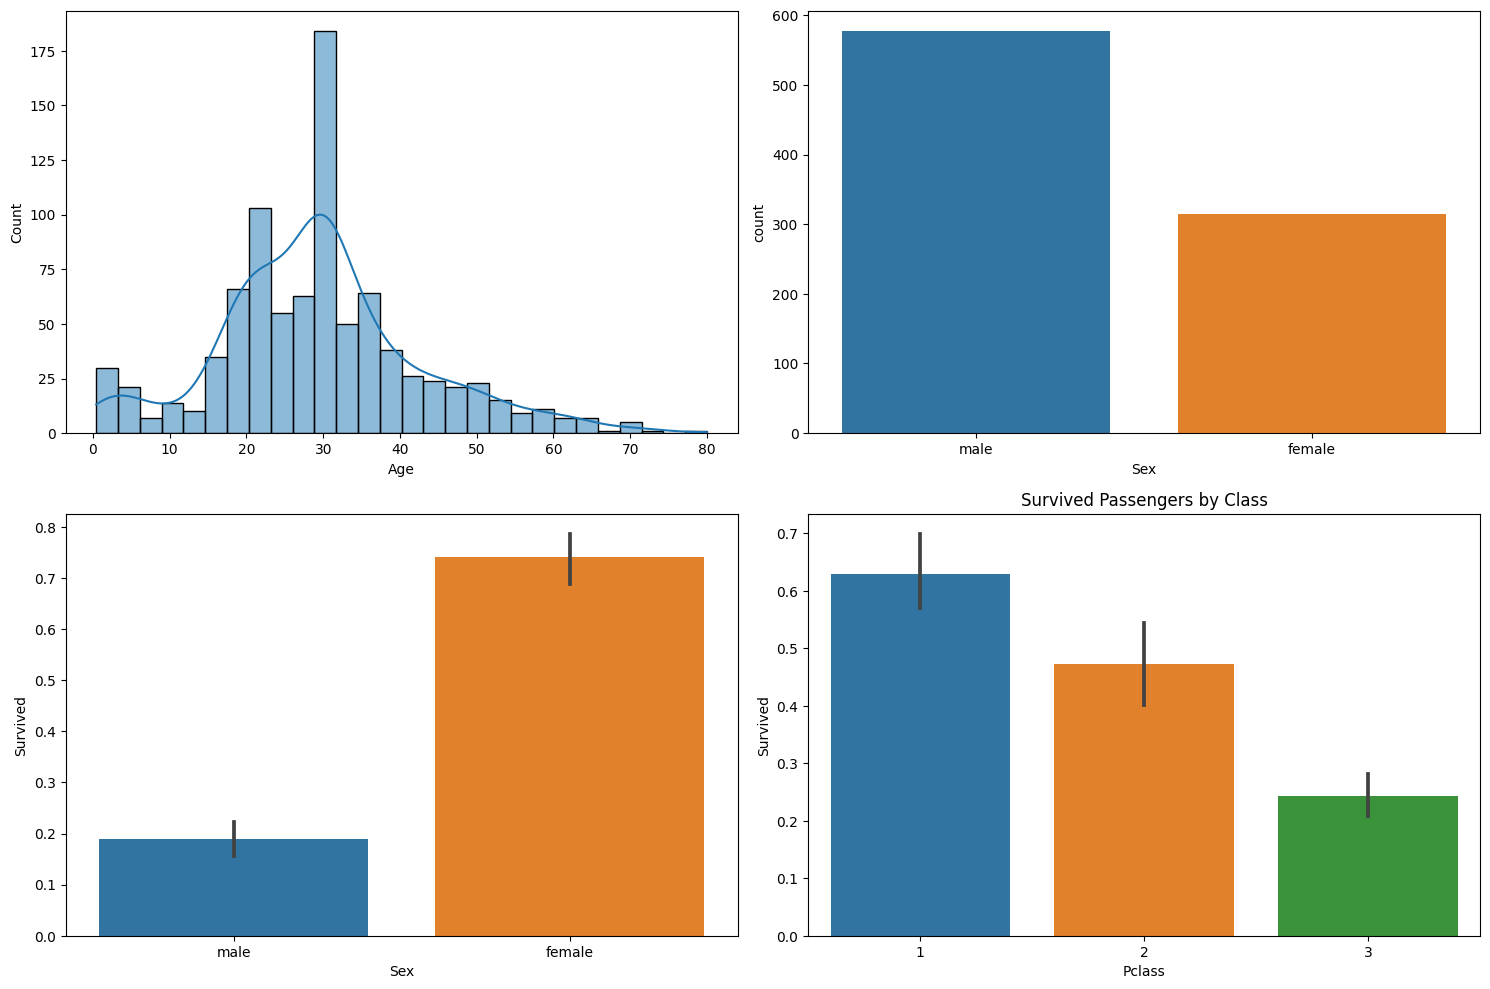

In [22]:
fig, axes = plt.subplots(2,2, figsize=(15,10))
sns.histplot(df['Age'], kde=True, ax=axes[0, 0])
plt.title("Age Distribution")

sns.countplot(x='Sex' ,data=df, ax=axes[0,1])
plt.title("Passengers distribution by Sex")

sns.barplot(x='Sex', y='Survived', data=df, ax=axes[1,0])
plt.title('Survived Passengers by Sex')

sns.barplot(x='Pclass', y='Survived', data=df, ax=axes[1,1])
plt.title("Survived Passengers by Class")


plt.tight_layout()
plt.show()

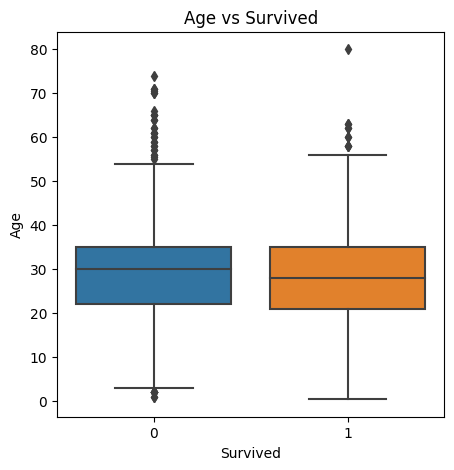

In [23]:
plt.figure(figsize=(5,5))
sns.boxplot(x='Survived', y = 'Age', data=df)
plt.title('Age vs Survived')
plt.show()

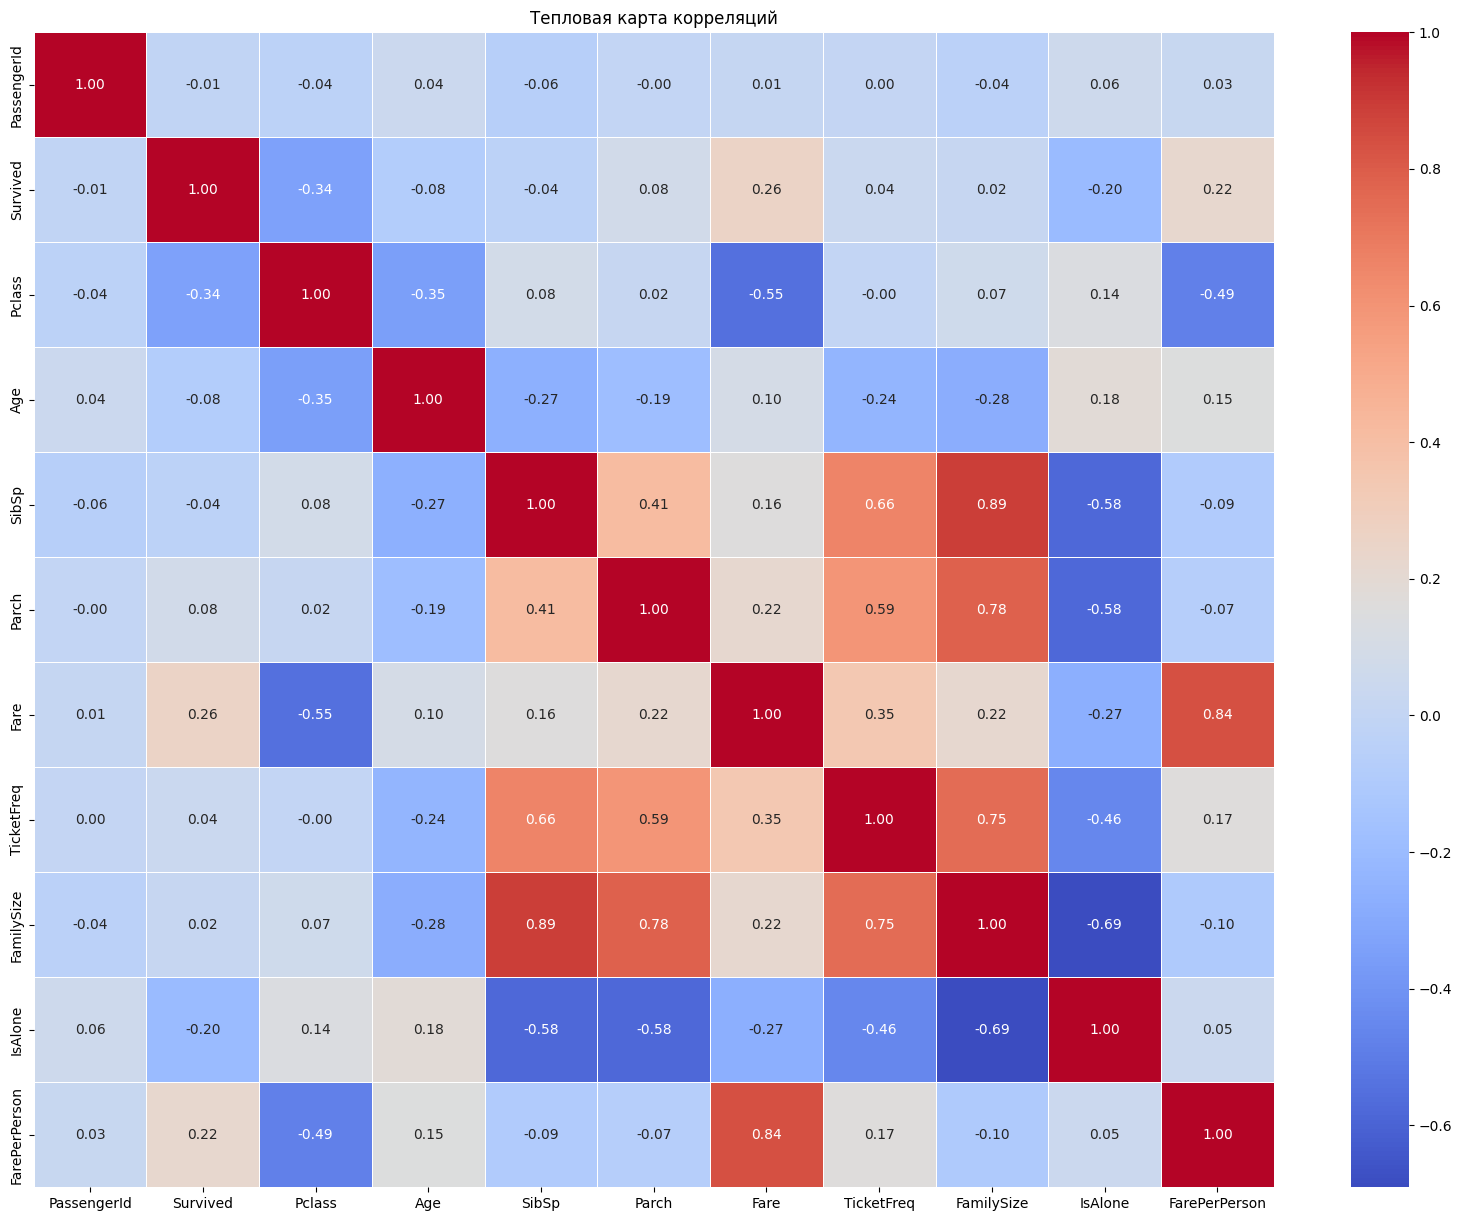

In [24]:
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(20, 15))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Тепловая карта корреляций')
plt.show()

### Encoding

In [25]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked', 'Deck', 'TicketFreq', 'Title',
       'FamilySize', 'IsAlone', 'AgeGroup', 'FarePerPerson', 'TicketGroup'],
      dtype='object')

In [26]:
df = df.copy()
tdf = tdf.copy()

In [27]:
label_encoder = preprocessing.LabelEncoder()
label_encoder.fit(df["Sex"])
df["Sex"] = label_encoder.transform(df["Sex"])
df.head()

label_encoder.fit(tdf["Sex"])
tdf["Sex"] = label_encoder.transform(tdf["Sex"])

In [28]:
tdf.isnull().sum()

PassengerId       0
Pclass            0
Name              0
Sex               0
Age               0
SibSp             0
Parch             0
Ticket            0
Fare              1
Embarked          0
Deck              0
TicketFreq        0
Title             0
FamilySize        0
IsAlone           0
AgeGroup          0
FarePerPerson     1
TicketGroup      97
dtype: int64

In [29]:
df['Pclass'].value_counts()
one_hot_encoder = preprocessing.OneHotEncoder()
one_hot_encoder.fit(df['Pclass'].values.reshape(-1, 1))
x_new = one_hot_encoder.transform(df['Pclass'].values.reshape(-1, 1)).toarray()

tdf['Pclass'].value_counts()
x_new_tdf = one_hot_encoder.transform(tdf['Pclass'].values.reshape(-1, 1)).toarray()

In [30]:
encoded_columns = one_hot_encoder.get_feature_names_out(['Pclass'])
encoded_df = pd.DataFrame(x_new, columns=encoded_columns)
df = pd.concat([df, encoded_df], axis=1)
df.drop(columns=['Pclass'], inplace=True)
df.head()

encoded_columns_tdf = one_hot_encoder.get_feature_names_out(['Pclass'])
encoded_tdf = pd.DataFrame(x_new_tdf, columns=encoded_columns_tdf)
tdf = pd.concat([tdf, encoded_tdf], axis=1)
tdf.drop(columns=['Pclass'], inplace=True)

In [31]:
tdf.isnull().sum()

PassengerId       0
Name              0
Sex               0
Age               0
SibSp             0
Parch             0
Ticket            0
Fare              1
Embarked          0
Deck              0
TicketFreq        0
Title             0
FamilySize        0
IsAlone           0
AgeGroup          0
FarePerPerson     1
TicketGroup      97
Pclass_1          0
Pclass_2          0
Pclass_3          0
dtype: int64

In [32]:
df['AgeGroup'].value_counts()
one_hot_encoder.fit(df['AgeGroup'].values.reshape(-1, 1))
x_new_age = one_hot_encoder.transform(df['AgeGroup'].values.reshape(-1, 1)).toarray()

tdf['AgeGroup'].value_counts()
x_new_age_tdf = one_hot_encoder.transform(tdf['AgeGroup'].values.reshape(-1, 1)).toarray()

In [33]:
encoded_columns_age = one_hot_encoder.get_feature_names_out(['AgeGroup'])
encoded_df_age = pd.DataFrame(x_new_age, columns=encoded_columns_age)
df = pd.concat([df, encoded_df_age], axis=1)
df.drop(columns=['AgeGroup'], inplace=True)
df.head()

encoded_df_age_tdf = pd.DataFrame(x_new_age_tdf, columns=encoded_columns_age)
tdf = pd.concat([tdf, encoded_df_age_tdf], axis=1)
tdf.drop(columns=['AgeGroup'], inplace=True)

In [34]:
tdf.isnull().sum()

PassengerId         0
Name                0
Sex                 0
Age                 0
SibSp               0
Parch               0
Ticket              0
Fare                1
Embarked            0
Deck                0
TicketFreq          0
Title               0
FamilySize          0
IsAlone             0
FarePerPerson       1
TicketGroup        97
Pclass_1            0
Pclass_2            0
Pclass_3            0
AgeGroup_Adult      0
AgeGroup_Baby       0
AgeGroup_Child      0
AgeGroup_Senior     0
AgeGroup_Teen       0
AgeGroup_Young      0
dtype: int64

In [35]:
df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

tdf['Embarked'] = tdf['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

In [36]:
scaler = preprocessing.RobustScaler()
df['Age_scaled'] = scaler.fit_transform(df[['Age']])
df.drop(columns=['Age'], inplace=True)
df.head()

tdf['Age_scaled'] = scaler.transform(tdf[['Age']])
tdf.drop(columns=['Age'], inplace=True)

In [37]:
df = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Fare', 'IsAlone'])

tdf = tdf.drop(columns=['PassengerId', 'Name', 'Ticket', 'Fare', 'IsAlone'])

In [38]:
df['FarePerPerson_log'] = np.log1p(df['FarePerPerson'])
df.head()

tdf['FarePerPerson'] = tdf['FarePerPerson'].fillna(tdf['FarePerPerson'].median())
tdf['FarePerPerson_log'] = np.log1p(tdf['FarePerPerson'])

In [39]:
df = pd.get_dummies(df, columns=['Deck', 'Title', 'TicketGroup'], prefix=['Deck', 'Title', 'TicketGroup'])
df.head()

tdf = pd.get_dummies(tdf, columns=['Deck', 'Title', 'TicketGroup'], prefix=['Deck', 'Title', 'TicketGroup'])


In [40]:
nan_columns = tdf.columns[tdf.isnull().any()].tolist()
print(f"Колонки с NaN: {nan_columns}")

Колонки с NaN: []


### Learning

In [41]:
X = df.drop('Survived', axis=1)
y = df['Survived']

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

In [42]:
X_test = tdf

In [43]:
feature_columns = X_train.columns.tolist()
for col in feature_columns:
    if col not in X_test.columns:
        X_test[col] = 0
X_test = X_test[feature_columns]

In [44]:
def predict_results(model, X_train, X_valid, y_train, y_valid):

    model.fit(X_train, y_train)

    y_pred = model.predict(X_valid)

    accuracy = accuracy_score(y_valid, y_pred)
    precision = precision_score(y_valid, y_pred)
    recall = recall_score(y_valid, y_pred)
    f1 = f1_score(y_valid, y_pred)

    print(f"Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}")

    ConfusionMatrixDisplay.from_estimator(model, X_valid, y_valid)
    plt.show()

In [45]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

Accuracy: 0.8324, Precision: 0.8056, Recall: 0.7838, F1-score: 0.7945


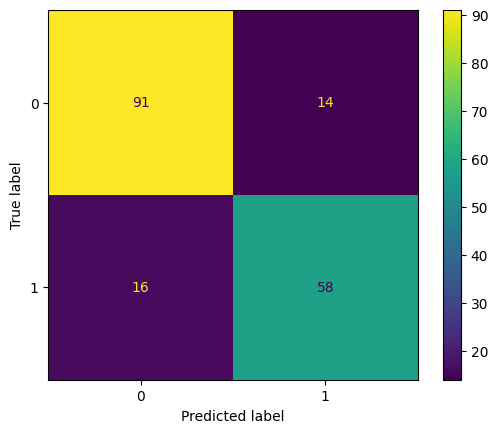

In [46]:
predict_results(rf_model, X_train, X_valid, y_train, y_valid)

In [47]:
param_grid = {
'n_estimators': [100, 200, 300],
'max_depth': [None, 10, 20, 30],
'min_samples_split': [2, 5, 10],
'min_samples_leaf': [1, 2, 4],
'max_features': ['sqrt', 'log2', None]
}

rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
estimator=rf,
param_grid=param_grid,
cv=5,
scoring='accuracy',
n_jobs=-1
)

grid_search.fit(X_train, y_train)

print(grid_search.best_params_)

best_rf = grid_search.best_estimator_

{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}


Accuracy: 0.8492, Precision: 0.8310, Recall: 0.7973, F1-score: 0.8138


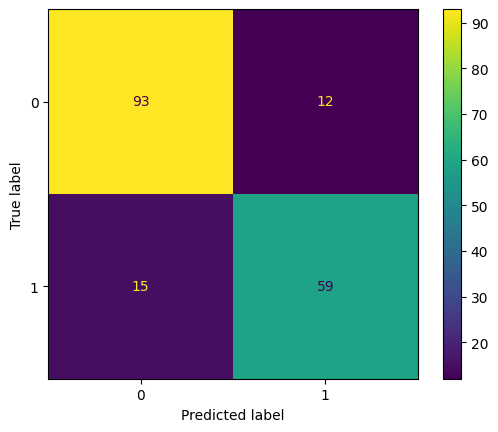

In [48]:
predict_results(best_rf, X_train, X_valid, y_train, y_valid)

In [ ]:
param_dist = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(3, 12),
    'min_samples_split': randint(2, 11),
    'min_samples_leaf': randint(1, 5),
    'max_features': ['sqrt', 'log2', None]
}

rf = RandomForestClassifier(random_state=42)

search = RandomizedSearchCV(
    rf, param_distributions=param_dist,
    n_iter=50, cv=5, scoring='accuracy', random_state=42, n_jobs=-1
)

search.fit(X_train, y_train)

best_rf_random = search.best_estimator_
print("Лучшие параметры:", search.best_params_)

In [ ]:
predict_results(best_rf_random, X_train, X_valid, y_train, y_valid)

In [49]:
importances = best_rf.feature_importances_
features = X_train.columns
importance_df = pd.DataFrame({'feature': features, 'importance': importances}).sort_values('importance', ascending=False)
print(importance_df)

               feature  importance
0                  Sex    0.180701
29            Title_Mr    0.121286
17   FarePerPerson_log    0.100547
6        FarePerPerson    0.099015
16          Age_scaled    0.081321
30           Title_Mrs    0.055630
9             Pclass_3    0.046921
4           TicketFreq    0.043399
28          Title_Miss    0.037028
5           FamilySize    0.033046
26              Deck_U    0.030446
3             Embarked    0.020654
1                SibSp    0.019974
8             Pclass_2    0.015432
2                Parch    0.014930
7             Pclass_1    0.013350
32  TicketGroup_Single    0.012071
10      AgeGroup_Adult    0.011448
15      AgeGroup_Young    0.010805
27        Title_Master    0.008939
22              Deck_E    0.006708
19              Deck_B    0.006147
31          Title_Rare    0.004954
13     AgeGroup_Senior    0.004566
11       AgeGroup_Baby    0.004465
20              Deck_C    0.003957
21              Deck_D    0.003368
12      AgeGroup_Chi

In [50]:
predictions = best_rf.predict(X_test)

In [52]:
kaggle_predictions = pd.DataFrame({
        "PassengerId": test_df["PassengerId"],
        "Survived": (predictions >= 0.5).astype(int)
    })

In [54]:
def make_submission(kaggle_predictions):
    path="/kaggle/working/submission.csv"
    kaggle_predictions.to_csv(path, index=False)
    print(f"Submission exported to {path}")

In [55]:
make_submission(kaggle_predictions)

Submission exported to /kaggle/working/submission.csv
